# Lidov–Kozai Resonances

This notebook demonstrates the dedicated `LidovKozaiResonance` class, the conserved quantities $c_1$, $c_2$, and $c$, and a 200 kyr simulation for three reference asteroids (1373 Cincinnati, 3040 Kozai, 15527). It can be used to identify the Lidov-Kozai resonances for the given asteroid(s).

Note that a simulation may contain multiple resonances or type of resonances.

## Analytical Invariants

The classical LK invariants follow the quadrupole solution of the circular restricted three-body problem:

$$c_1 = (1 - e^2)\cos^2 i$$

$$c_2=(1-\epsilon)\left(\frac{2}{5}-\sin^2 i \sin^2 \omega\right)=e^2\left(\frac{2}{5}-\sin^2 i \sin^2 \omega\right)$$

$$c = (2 + 3e^2)(3\cos^2 i - 1) + 15 e^2 \sin^2 i \cos (2\omega)$$

Objects with $c_1 \le 3/5$ and $c_2 < 0$ can librate around $|\omega| = 90^\circ$.

In [1]:
import numpy as np
from resonances import LidovKozaiParameters

samples = [
    ("1373 Cincinnati", 0.3157197965003622, 38.94710189440708, 99.00994425115446),
    ("3040 Kozai", 0.200325965974545, 46.64758743804768, 290.188539070968),
    ("15527", 0.1536785059545885, 21.270454900247717, 169.13213746428102),
]

for name, e, inc_deg, omega_deg in samples:
    inc = np.deg2rad(inc_deg)
    omega = np.deg2rad(omega_deg)
    c1, c2, c = LidovKozaiParameters.evaluate(e, inc, omega)
    print(f"{name:<16} e={e:.3f}, i={inc_deg:.2f} deg, omega={omega_deg:.2f} deg -> c1={c1:.3f}, c2={c2:.3f}, c={c:.3f}")

1373 Cincinnati  e=0.316, i=38.94 deg, omega=99.00 deg -> c1=0.545, c2=1.312, c=0.001
3040 Kozai       e=0.200, i=46.64 deg, omega=290.15 deg -> c1=0.452, c2=0.635, c=-0.003
15527            e=0.154, i=21.26 deg, omega=169.17 deg -> c1=0.848, c2=3.368, c=0.009


## Numerical Experiment (200 kyr)

We propagate asteroids 1373, 3040, and 15527 for `200,000` years using `ias15` ($dt=1$ day). `ias15` is chosen because some of the asteroids considered have dynamical evolution. 1373 and 3040 are classical LK objects; 15527 is outside the libration island.

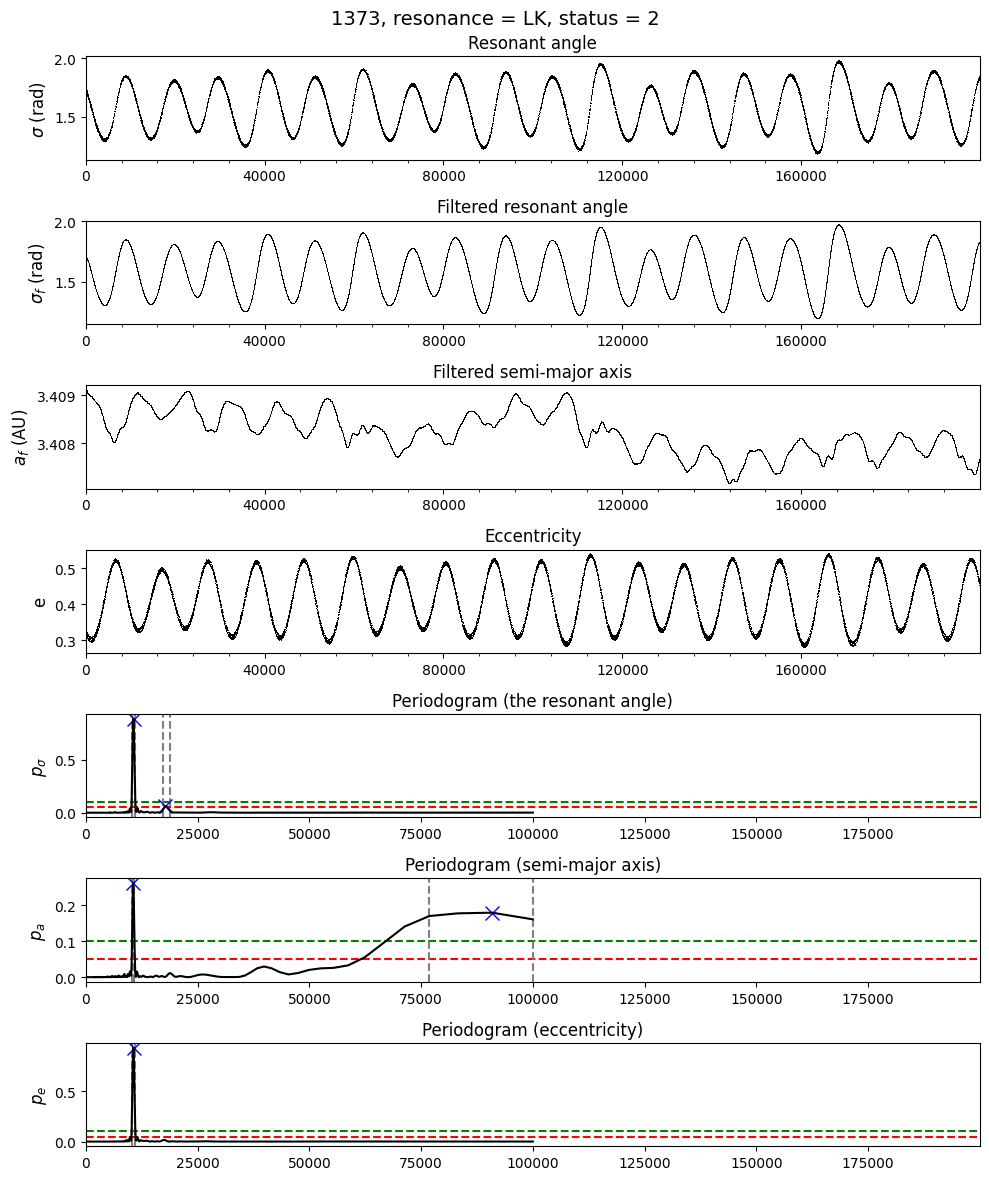

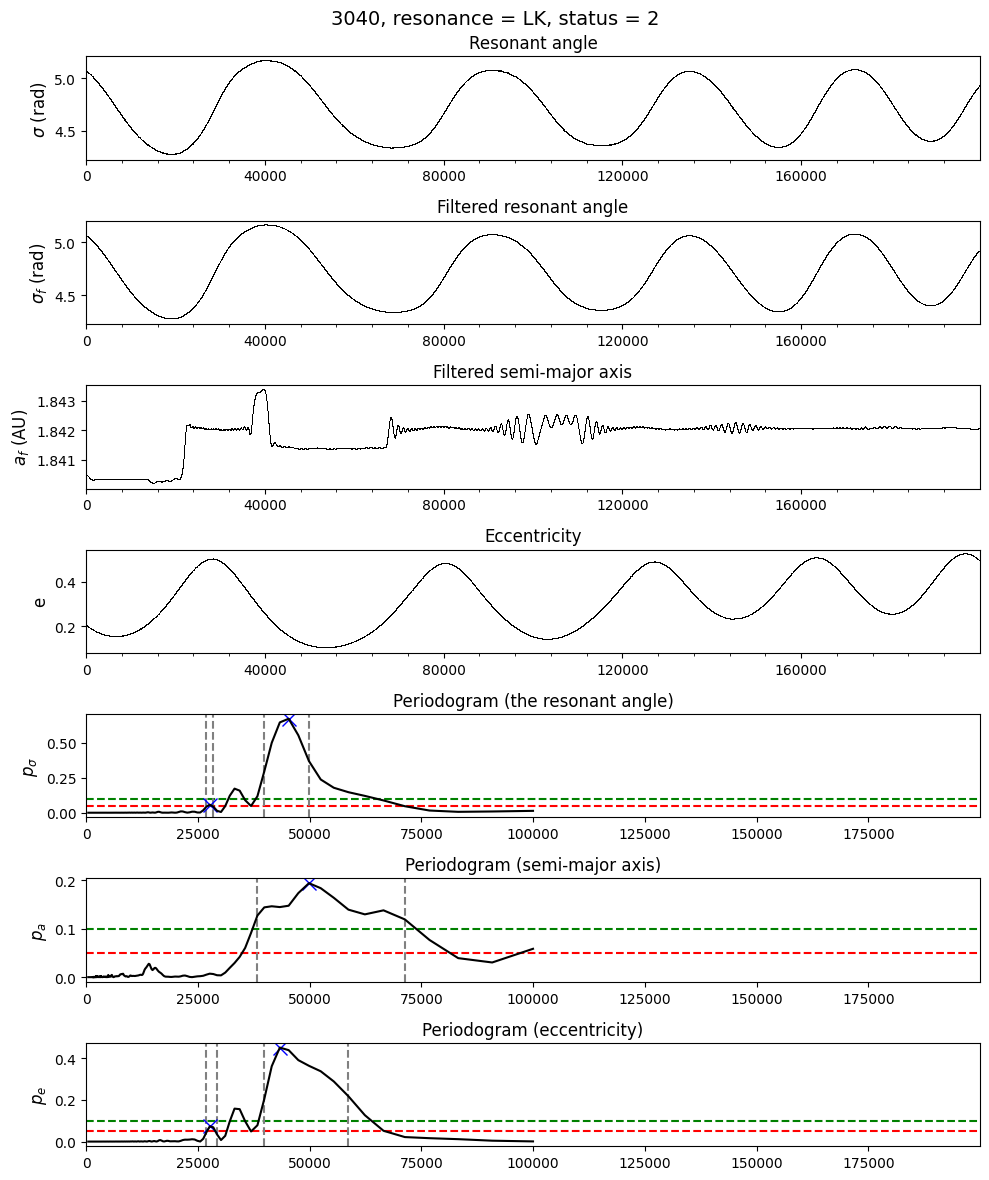

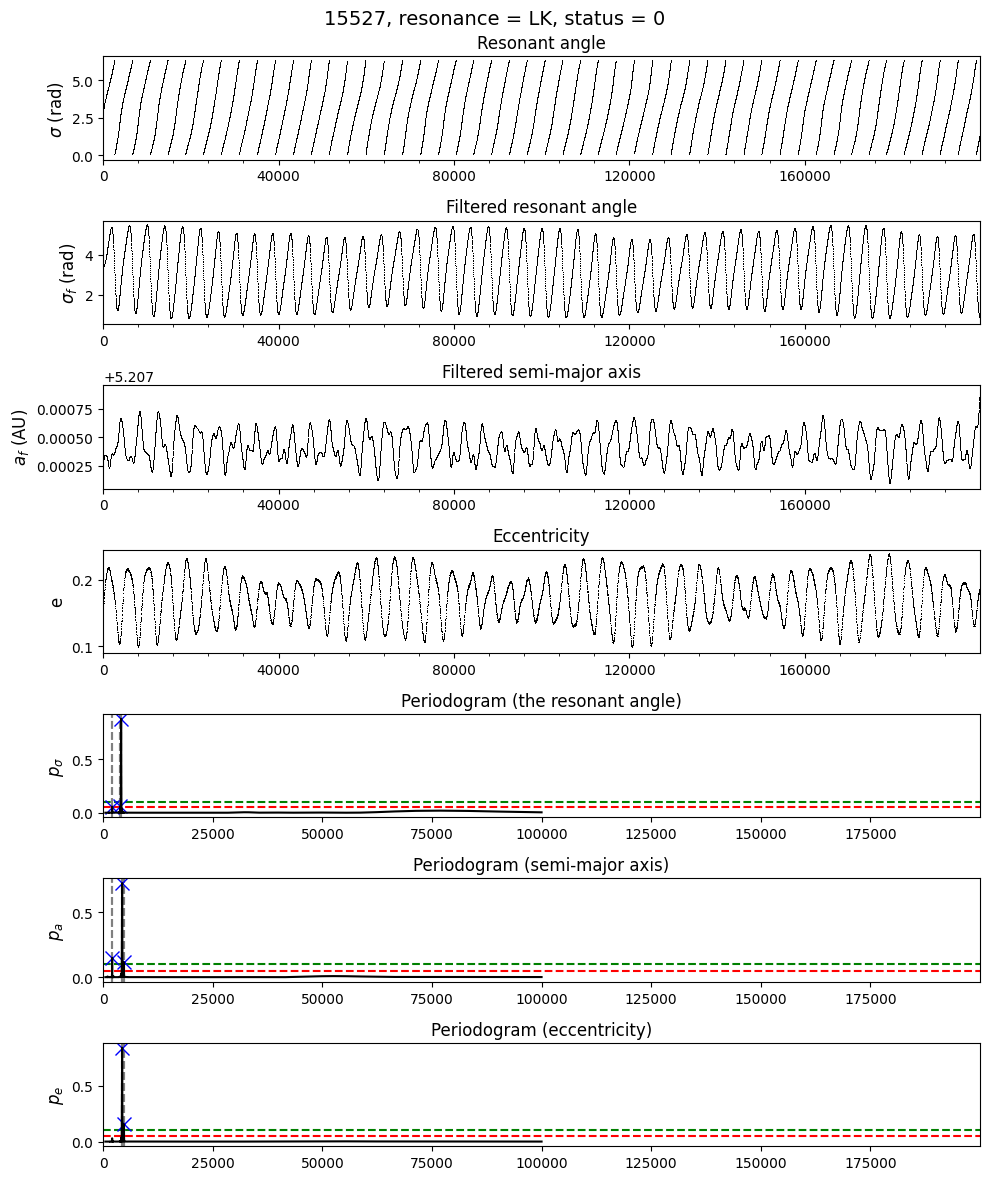

 name resonance  status       c1       c2         c
 1373        LK       2 0.544666 1.310294  0.001410
 3040        LK       2 0.452367 0.635268 -0.002631
15527        LK       0 0.848251 3.366409  0.009230


In [2]:
import numpy as np
import pandas as pd
import resonances

ASTEROIDS = [1373, 3040, 15527]
config = dict(
    tmax=int(200_000 * 2 * np.pi),
    integrator='ias15',
    dt=1.0,
    save=None,
    plot="all",
    plot_type="show",
    save_summary=False,
)

sim = resonances.Simulation(name='lk_notebook', source='astdys', **config)
sim.create_solar_system()
for asteroid in ASTEROIDS:
    sim.add_body(asteroid, resonances.LidovKozaiResonance(), name=str(asteroid))

sim.run(progress=False)
summary = sim.data_manager.get_simulation_summary(sim.bodies)
display_cols = ['name', 'resonance', 'status', 'c1', 'c2', 'c']
print(summary[display_cols].to_string(index=False))

### Resonant Angle Evolution

The plots below show the argument of pericenter for the resonant asteroids (phase wrapping is expected).

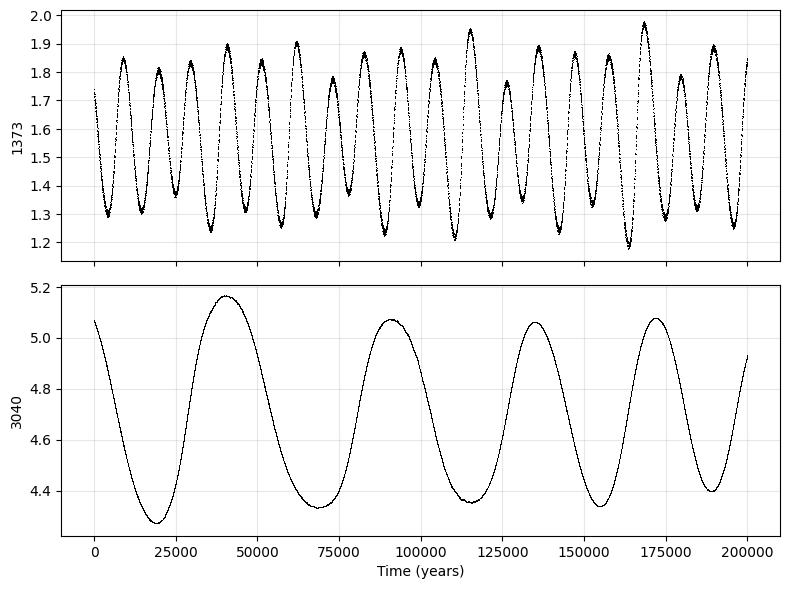

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
resonance = resonances.LidovKozaiResonance()
for idx, asteroid in enumerate([1373, 3040]):
    body = next(body for body in sim.bodies if body.name == str(asteroid))
    angle = body.angle(resonance)
    time_years = sim.times / (2 * np.pi)
    axs[idx].plot(time_years, angle, ',', color='black')
    axs[idx].set_ylabel(f"{asteroid}")
    axs[idx].grid(alpha=0.3)
axs[-1].set_xlabel('Time (years)')
plt.tight_layout()